In [1]:
#Imports
from pathlib import Path
from PIL import Image
from src.model import load_model
from src.evaluation import evaluate_dataset2, plot_histogram, predict_full_image, plot_compare_masks, plot_compare_masks_version2, plot_mask_venn, hex_to_rgb, save_predictions_and_overlays, measure_average_inference_time, DSD_from_image, DSD_from_mask, summarize_dsd_errors,create_dsd_comparison_dataframe
import numpy as np
from src.mask_analysis import diameter_stats, diameter_error_stats, phase_fractions, phase_pixel_counts
import csv
import matplotlib.pyplot as plt
import shutil
import pandas as pd


c:\Users\47469\master_enviorment\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


"""
test_model.ipynb

Purpose:
    Interactive evaluation and visualization of trained U-Net models.

Includes:
    - Test set evaluation
    - DSD analysis
    - Phase fraction analysis
    - Qualitative segmentation inspection
    - Comparison of multiple trained models

This notebook is intended for exploration and analysis rather than
reproducible training.
"""

In [2]:
BASE_DIR = Path.cwd()

MODEL_RUNS = {
    "Spatially Augmented Dataset": BASE_DIR / "Latest_Models" / "NORMAL_no_aug",
    "Original Dataset": BASE_DIR / "Latest_Models" / "som orginaldatasett" / "u_net_no_aug",
    "No Pretraining": BASE_DIR / "Latest_Models" / "no_aug_no_weights",
    "PolyS Pretraining": BASE_DIR / "Latest_Models" / "PS_no_aug",
    "Million Bubble Pretraining": BASE_DIR / "Latest_Models" / "MB_no_aug",
    "More Intense Augmentations": BASE_DIR / "Latest_Models" / "different aug stratergies" / "aug_olf_full_no_dropout_no_shift",
    "Less Intense Augmentations": BASE_DIR / "Latest_Models" / "different aug stratergies" / "aug_light_full",
}

In [5]:
final_model_path = MODEL_RUNS["More Intense Augmentations"] / "best_model.pth"
final_model = load_model(final_model_path)
NAME = "HAD_test"



In [4]:
print(final_model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [6]:

BASE_DIR = Path.cwd()

TEST_DIR = BASE_DIR / "Test set"

ANNOTATED_DIR = TEST_DIR / "Annotated"
MASK_DIR = TEST_DIR / "Masks"
OLD_MICROSCOPE_DIR = TEST_DIR / "Not_annotated"
NEW_MICROSCOPE_DIR = TEST_DIR / "New_Microscope"
CSV_DIR = TEST_DIR / "CSV_results"
SAVED_PREDICTIONS_DIR = TEST_DIR / "Saved_Predictions"

Measure mean inference time for full-scale images

In [7]:
measure_average_inference_time(model=final_model, image_dir=Path(OLD_MICROSCOPE_DIR), threshold=0.5)

Measuring inference time: 100%|██████████| 37/37 [01:16<00:00,  2.06s/it]

Images: 37
Mean inference time: 2.0561 s/image
Std inference time:  0.5036 s
Min inference time:  1.4249 s
Max inference time:  3.6652 s


,image,inference_time_sec
0,199.jpg,1.670131
1,200.jpg,2.913669
2,201.jpg,2.337876
3,209.jpg,1.616704
4,210.jpg,1.526571
5,213.jpg,1.567602
6,216.jpg,1.480637
7,217.jpg,1.586370
8,240.jpg,1.700931
9,241.jpg,1.681541


Save your predictions as images in a folder

In [ ]:
YOUR_IMAGE_DIR = Path(r"  ") #<-- Change this to the path of your test images
save_predictions_and_overlays(model=final_model, model_name="name_for_test", image_dir=YOUR_IMAGE_DIR, save_dir=SAVED_PREDICTIONS_DIR, threshold=0.1)


Scales for Olympus (Old microscope) and Nikon (New Microscope)

In [15]:
zoom20= []
zoom200 = []
zoom100 = []
zoom50 = []
list20 = ["243", "362", "347", "352", "353"]
list200 = ["240"]
list100 =["241"]
list50 =["242"]
for img_path in ANNOTATED_DIR.iterdir():
    if img_path.name.startswith(tuple(list20)):
        zoom20.append(img_path)
    
    elif img_path.name.startswith(tuple(list200)):
        zoom200.append(img_path)
    elif img_path.name.startswith(tuple(list100)):
        zoom100.append(img_path)
    elif img_path.name.startswith(tuple(list50)):
        zoom50.append(img_path)

print(zoom20)
print(zoom200)
print(zoom100)
print(zoom50)

scales = dict()
scales["20x"] = 20/94 #60 times
scales["200x"] = 200/155 #40 times
scales["100x"] =100/155 #20 times
scales["50x"] = 50/155 #mikron/pixel 155 er gitt i pixle/mikron, 10 times
scales["new_10times"] = 1/4.12 #mikron/pixel 4.12 er gitt i pixle/mikron
scales["new_20times"] = 1/8.1630
scales["new_50times"] = 1/(8.1630*2.5)



[WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_0_0.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_0_256.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_0_512.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_0_768.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_1024_0.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_1024_256.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_1024_512.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_1024_768.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_256_0.tif'), WindowsPath('c:/Users/47469/master_enviorment/Github Model/Test set/Annotated/243_tile_256_

In [ ]:
OUTPUT_DIR = Path(TEST_DIR / "Zoom_groups")
folders = {
    "20x": OUTPUT_DIR / "20x",
    "50x": OUTPUT_DIR / "50x",
    "100x": OUTPUT_DIR / "100x",
    "200x": OUTPUT_DIR / "200x",
}

for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

# =========================
# SORT FILES
# =========================

for img_path in ANNOTATED_DIR.iterdir():

    if not img_path.is_file():
        continue

    if img_path.name.startswith(tuple(list20)):
        shutil.copy(img_path, folders["20x"] / img_path.name)

    elif img_path.name.startswith(tuple(list50)):
        shutil.copy(img_path, folders["50x"] / img_path.name)

    elif img_path.name.startswith(tuple(list100)):
        shutil.copy(img_path, folders["100x"] / img_path.name)

    elif img_path.name.startswith(tuple(list200)):
        shutil.copy(img_path, folders["200x"] / img_path.name)

Making and saving predicitions for the different magnification (values in micro meters according to the scaling factors)

In [ ]:
df_20x, gt_20x, raw_20x, post_20x, masks_20x = evaluate_dataset2(
    model=final_model,
    input_dir=folders["20x"],
    mask_dir=MASK_DIR,
    microns_per_pixel=scales["20x"],
)
#df_20x.to_csv(CSV_DIR / f"{NAME}_20x_results.csv", index=False) # <-- Uncomment this line to save the results to a CSV file

df_50x, gt_50x, raw_50x, post_50x, masks_50x = evaluate_dataset2(
    model=final_model, 
    input_dir=folders["50x"],
    mask_dir=MASK_DIR,
    microns_per_pixel=scales["50x"],
)
#df_50x.to_csv(CSV_DIR / f"{NAME}_50x_results.csv", index=False) # <-- Uncomment this line to save the results to a CSV file

df_100x, gt_100x, raw_100x, post_100x, masks_100x = evaluate_dataset2(
    model=final_model,
    input_dir=folders["100x"],
    mask_dir=MASK_DIR,
    microns_per_pixel=scales["100x"],
)
#df_100x.to_csv(CSV_DIR / f"{NAME}_100x_results.csv", index=False) # <-- Uncomment this line to save the results to a CSV file

df_200x, gt_200x, raw_200x, post_200x, masks_200x = evaluate_dataset2(
    model=final_model,
    input_dir=folders["200x"],
    mask_dir=MASK_DIR,
    microns_per_pixel=scales["200x"],
)
#df_200x.to_csv(CSV_DIR / f"{NAME}_200x_results.csv", index=False) # <-- Uncomment this line to save the results to a CSV file

243_tile_0_0.tif: {'count': 55, 'mean': 11.14484, 'median': 8.44402, 'std': 7.82448, 'min': 2.98541, 'max': 39.8623}
243_tile_0_0.tif: GT (256, 256), raw (256, 256), Dice raw=0.778, Dice post=0.774
243_tile_0_256.tif: {'count': 43, 'mean': 12.76958, 'median': 8.95623, 'std': 11.76684, 'min': 2.76395, 'max': 57.94422}
243_tile_0_256.tif: GT (256, 256), raw (256, 256), Dice raw=0.862, Dice post=0.867
243_tile_0_512.tif: {'count': 40, 'mean': 12.41028, 'median': 7.72876, 'std': 12.44863, 'min': 3.56825, 'max': 77.68626}
243_tile_0_512.tif: GT (256, 256), raw (256, 256), Dice raw=0.866, Dice post=0.866
243_tile_0_768.tif: {'count': 51, 'mean': 9.99935, 'median': 7.89865, 'std': 7.75671, 'min': 2.52313, 'max': 45.55634}
243_tile_0_768.tif: GT (256, 256), raw (256, 256), Dice raw=0.775, Dice post=0.775
243_tile_1024_0.tif: {'count': 46, 'mean': 11.84238, 'median': 8.36828, 'std': 8.13565, 'min': 2.52313, 'max': 34.59545}
243_tile_1024_0.tif: GT (256, 256), raw (256, 256), Dice raw=0.853, Dic

Same thing but globally for all annotated test images (this time diameters in pixels)

In [9]:
eval_df, gt_d, raw_d, post_d, masks = evaluate_dataset2(
    model=final_model,
    input_dir=ANNOTATED_DIR,
    mask_dir=MASK_DIR,
)
#eval_df.to_csv(CSV_DIR / f"{NAME}_full_results.csv", index=False) # <-- Uncomment this line to save the results to a CSV file



240_tile_0_0.tif: GT (512, 512), raw (512, 512), Dice raw=0.469, Dice post=0.465
240_tile_512_512.tif: GT (512, 512), raw (512, 512), Dice raw=0.675, Dice post=0.675
241_tile_0_0.tif: GT (512, 512), raw (512, 512), Dice raw=0.794, Dice post=0.794
241_tile_512_512.tif: GT (512, 512), raw (512, 512), Dice raw=0.811, Dice post=0.811
242_tile_0_0.tif: GT (512, 512), raw (512, 512), Dice raw=0.809, Dice post=0.810
242_tile_512_512.tif: GT (512, 512), raw (512, 512), Dice raw=0.759, Dice post=0.758
243_tile_0_0.tif: GT (256, 256), raw (256, 256), Dice raw=0.778, Dice post=0.774
243_tile_0_256.tif: GT (256, 256), raw (256, 256), Dice raw=0.862, Dice post=0.867
243_tile_0_512.tif: GT (256, 256), raw (256, 256), Dice raw=0.866, Dice post=0.866
243_tile_0_768.tif: GT (256, 256), raw (256, 256), Dice raw=0.775, Dice post=0.775
243_tile_1024_0.tif: GT (256, 256), raw (256, 256), Dice raw=0.853, Dice post=0.853
243_tile_1024_256.tif: GT (256, 256), raw (256, 256), Dice raw=0.781, Dice post=0.780
24

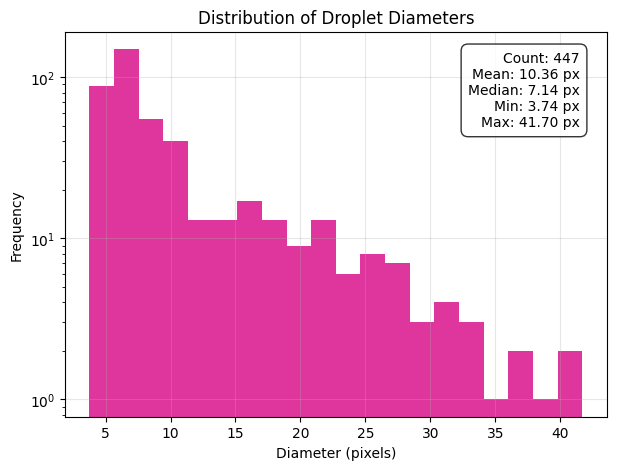

In [10]:
img_name = list(masks.keys())[-1] 
org_img = np.array(Image.open(ANNOTATED_DIR / img_name).convert("L"))
gt_mask = masks[img_name]["gt"]
raw_mask = masks[img_name]["raw"]
post_mask = masks[img_name]["post"]

plot_histogram(raw_mask)



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def plot_gt_and_prediction(model, image_path, gt_mask_path, threshold=0.5):
    gt = np.array(Image.open(gt_mask_path).convert("L")) > 0

    pred = predict_full_image(
        model,
        image_path,
        postprocess=False
    )
    pred.keys()
    pred =pred["raw_mask"]

    if hasattr(pred, "cpu"):
        pred = pred.cpu().numpy()

    pred = np.squeeze(pred)

    # Hvis predict_full_image returnerer sannsynligheter
    pred = pred > threshold

    print("GT shape:  ", gt.shape)
    print("Pred shape:", pred.shape)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground truth mask")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted mask")
    plt.axis("off")
    gt_bool = gt > 0
    pred_bool = pred > 0

    intersection = np.logical_and(gt_bool, pred_bool).sum()
    dice = (2 * intersection) / (gt_bool.sum() + pred_bool.sum() + 1e-8)

    print("GT pixels:", gt_bool.sum())
    print("Pred pixels:", pred_bool.sum())
    print("Intersection:", intersection)
    print("Dice:", dice)

    plt.show()

In [12]:
img_name = list(masks_20x.keys())[22] 
org_img = np.array(Image.open(ANNOTATED_DIR / img_name).convert("L"))
gt_mask = masks[img_name]["gt"]
raw_mask = masks[img_name]["raw"]
post_mask = masks[img_name]["post"]

plot_mask_venn(raw_mask, post_mask, title=img_name, al=True, loc_text="lower left")

NameError: name 'masks_20x' is not defined

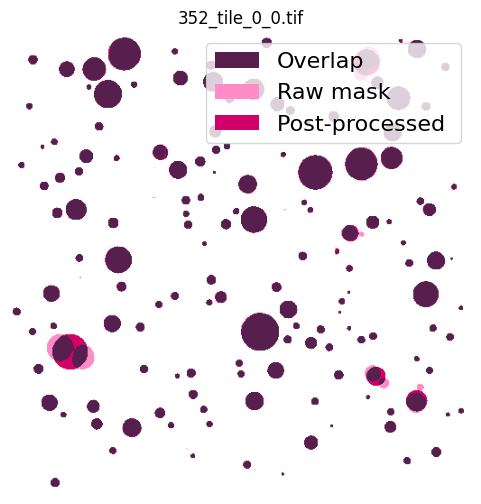

In [19]:
plot_mask_venn(raw_mask, post_mask, title=img_name, al=True)

DSD evaluation

In [20]:
DSD_df = create_dsd_comparison_dataframe(
    masks=masks,
    annotated_dir=ANNOTATED_DIR,
    pred_key="raw",
    microns_per_pixel=None)



In [21]:
DSD_20df = create_dsd_comparison_dataframe(
    masks=masks_20x,
    annotated_dir=ANNOTATED_DIR,
    pred_key="raw",
    microns_per_pixel=scales["20x"])
summarize_dsd_errors(DSD_20df)

#DSD_20x_gt = DSD_from_mask(gt_mask, microns_per_pixel=scales["20x"])
#DSD_20x_gt["mean"]

(abs(DSD_20df["gt_mean"]-DSD_20df["pred_mean"])/DSD_20df["gt_mean"]).mean()


np.float64(0.17857573853082062)

In [22]:
DSD_50df = create_dsd_comparison_dataframe(
    masks=masks_50x,
    annotated_dir=ANNOTATED_DIR,
    pred_key="raw",
    microns_per_pixel=scales["50x"]
)
summarize_dsd_errors(DSD_50df)  

,metric,mse,rmse,mae,bias,std_error
0,mean,0.010726,0.103565,0.092185,0.047198,0.092185
1,median,0.007582,0.087074,0.084413,0.084413,0.021363
2,std,0.148059,0.384784,0.384752,0.384752,0.004943
3,d10,0.639164,0.799477,0.752740,-0.752740,0.269343
4,d50,0.007582,0.087074,0.084413,0.084413,0.021363
5,d90,0.556426,0.745939,0.680264,0.680264,0.306051
6,span,0.158670,0.398333,0.396677,0.396677,0.036293
7,d32,0.270953,0.520531,0.517798,0.517798,0.053272
8,cv,0.007484,0.086513,0.085679,0.085679,0.011983


In [23]:
DSD_100df = create_dsd_comparison_dataframe(
    masks=masks_100x,
    annotated_dir=ANNOTATED_DIR,
    pred_key="raw",
    microns_per_pixel=scales["100x"]
)
summarize_dsd_errors(DSD_100df)     

,metric,mse,rmse,mae,bias,std_error
0,mean,0.813111,0.901727,0.814428,0.814428,0.387063
1,median,1.216264,1.102844,1.045017,1.045017,0.352426
2,std,0.268646,0.518311,0.479413,0.479413,0.197001
3,d10,0.181607,0.426154,0.375989,-0.375989,0.200597
4,d50,1.216264,1.102844,1.045017,1.045017,0.352426
5,d90,1.970684,1.403810,1.223493,1.223493,0.688293
6,span,0.002277,0.047722,0.047472,0.047472,0.004881
7,d32,1.553259,1.246298,1.135957,1.135957,0.512701
8,cv,0.000308,0.017549,0.017535,0.017535,0.000697


In [24]:
DSD_200df = create_dsd_comparison_dataframe(
    masks=masks_200x,
    annotated_dir=ANNOTATED_DIR,
    pred_key="raw",
    microns_per_pixel=scales["200x"]
)
summarize_dsd_errors(DSD_200df)     

,metric,mse,rmse,mae,bias,std_error
0,mean,0.020037,0.141551,0.137140,0.137140,0.035063
1,median,0.035092,0.187330,0.179471,-0.179471,0.053691
2,std,0.289234,0.537805,0.518260,0.518260,0.143670
3,d10,0.553647,0.744074,0.738968,-0.738968,0.087020
4,d50,0.035092,0.187330,0.179471,-0.179471,0.053691
5,d90,2.213803,1.487885,1.449960,1.449960,0.333797
6,span,0.073808,0.271676,0.266470,0.266470,0.052928
7,d32,0.477063,0.690697,0.684443,0.684443,0.092739
8,cv,0.003184,0.056424,0.053110,0.053110,0.019053


240 DSDs

In [ ]:
pred_240 = predict_full_image(
    model=final_model,
    image_path=OLD_MICROSCOPE_DIR / "240.jpg",
    postprocess=False,
    plot=False,
    microns_per_pixel=scales["200x"],)

mask_240 = pred_240["raw_mask"]
DSD_240 = pred_240["dsd"]


print("DSD 240:", DSD_240["mean"]) #can also use DSD_function

plot_histogram(mask_240, m_per_p=scales["200x"])


DSD 240: 8.993931472802089


C:\Users\47469\AppData\Local\Temp\ipykernel_30524\167945021.py:58: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, ymax)


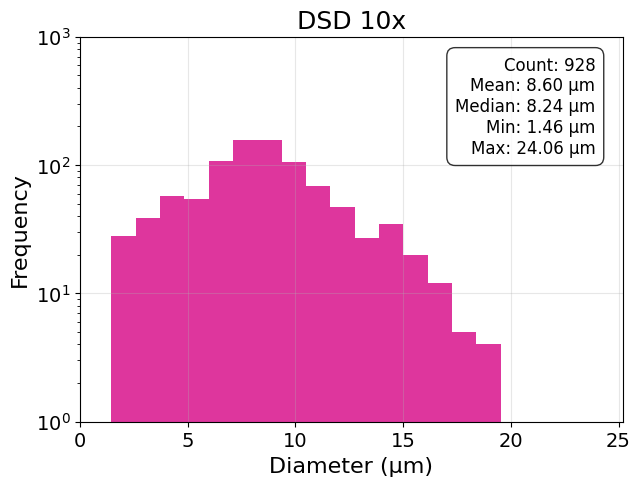

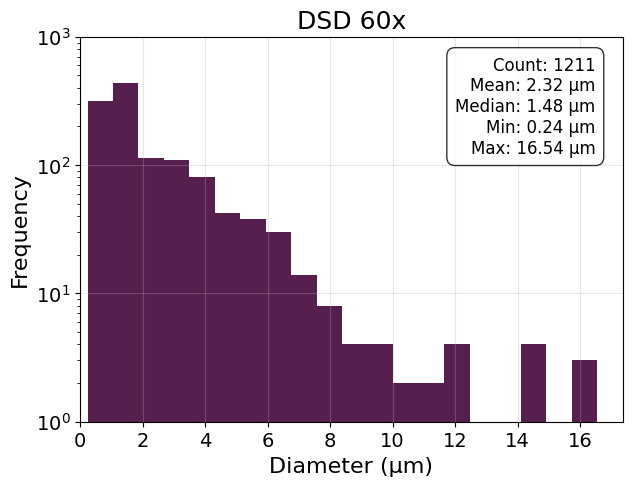

In [ ]:
from src.mask_analysis import diameters_from_mask

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip("#")
    return np.array(
        [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)],
        dtype=float
    )
colors = {
    "pink 1": hex_to_rgb("#FF8CC6"),
    "purple 1": hex_to_rgb("#571F4E"),
    "pink 3": hex_to_rgb("#D20069"),
    "pink 2": hex_to_rgb("#DE369D"),
    "purple 2" : hex_to_rgb("#6F5E76"),
}
def plot_histogram(mask, m_per_p=None, b=20, log=True, min_area_px=0, ymax=None, xmax=None, title=None, color=colors["purple 1"]):
    diameters = diameters_from_mask(
        mask,
        microns_per_pixel=m_per_p,
        min_area_px=min_area_px
    )

    diameter_print = diameter_stats(diameters)

    plt.figure(figsize=(7, 5))
    plt.hist(diameters, bins=b, log=log, color = color)

    if m_per_p is not None:
        plt.xlabel("Diameter (µm)", fontsize=16)
        unit = "µm"
    else:
        plt.xlabel("Diameter (pixels)", fontsize=16)
        unit = "px"

    plt.ylabel("Frequency", fontsize=16)
    plt.title(title, fontsize=18)
    plt.ylim(1, ymax)
    plt.xlim(0, xmax)
    plt.text(
        0.95,
        0.95,
        f"Count: {diameter_print['count']}\n"
        f"Mean: {diameter_print['mean']:.2f} {unit}\n"
        f"Median: {diameter_print['median']:.2f} {unit}\n"
        f"Min: {diameter_print['min']:.2f} {unit}\n"
        f"Max: {diameter_print['max']:.2f} {unit}",
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.8
        )
    )
    if ymax is not None:
        plt.ylim(0, ymax)
    if xmax is not None:
        plt.xlim(0, xmax)
    
    plt.tick_params(axis='both', labelsize=14)
    plt.grid(alpha=0.3)
    plt.show()
    
plot_histogram(mask_240, m_per_p=scales["200x"], ymax = 10**3, title="DSD 10x", color=colors["pink 2"])  


In [ ]:
print("240: ", phase_fractions(mask_240)["water_percent"])


240:  2.6204799032127974
241:  5.271835932248958
242:  10.337060872877178
243:  14.905047161356814
